## **4. Phân lớp**

### **4.1 Phương pháp XGboost**

**Bước 1: Import thư viện và tải dữ liệu**

In [2]:
import os
import pandas as pd
import numpy as np
from google.colab import files
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

print("Tải file CSV từ máy lên:")
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(file_name)
print("Dữ liệu:", df.shape)


Tải file CSV từ máy lên:


Saving loan_data_final_scaled.csv to loan_data_final_scaled.csv
Dữ liệu: (8620, 19)


**Nhận xét**

**Bước 2: Chuẩn bị dữ liệu và cân bằng lớp**

In [3]:
target = 'not.fully.paid'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Cân bằng lớp xong. Số mẫu train:", len(X_train_res))


Cân bằng lớp xong. Số mẫu train: 11652


**Nhận xét**

**Bước 3: Huấn luyện mô hình XGBoost và tối ưu tham số**

In [4]:
xgb = XGBClassifier(
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 4],
    'learning_rate': [0.03, 0.05],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid = GridSearchCV(
    xgb, param_grid,
    scoring='f1', cv=3, n_jobs=-1, verbose=0
)
grid.fit(X_train_res, y_train_res)
best_model = grid.best_estimator_

print("Best params:", grid.best_params_)


Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 300, 'subsample': 0.8}


**Nhận xét**

**Bước 4: Đánh giá mô hình và phân tích kết quả**

Accuracy: 0.780  |  ROC AUC: 0.620

=== Báo cáo phân lớp ===
              precision    recall  f1-score   support

           0      0.859     0.885     0.872      1456
           1      0.251     0.209     0.228       268

    accuracy                          0.780      1724
   macro avg      0.555     0.547     0.550      1724
weighted avg      0.764     0.780     0.772      1724



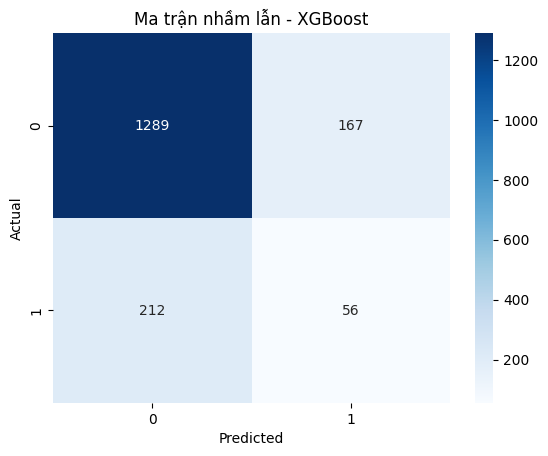

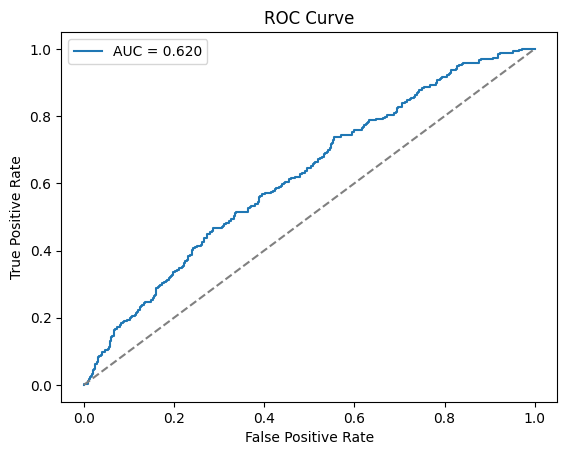


Top 10 đặc trưng quan trọng nhất:
                       Feature  Importance
8                credit.policy    0.204250
4                         fico    0.108208
12         purpose_credit_card    0.073912
0                     int.rate    0.072022
10                 delinq.2yrs    0.063429
17      purpose_small_business    0.059194
13  purpose_debt_consolidation    0.050227
15    purpose_home_improvement    0.049789
14         purpose_educational    0.045864
11                     pub.rec    0.039799


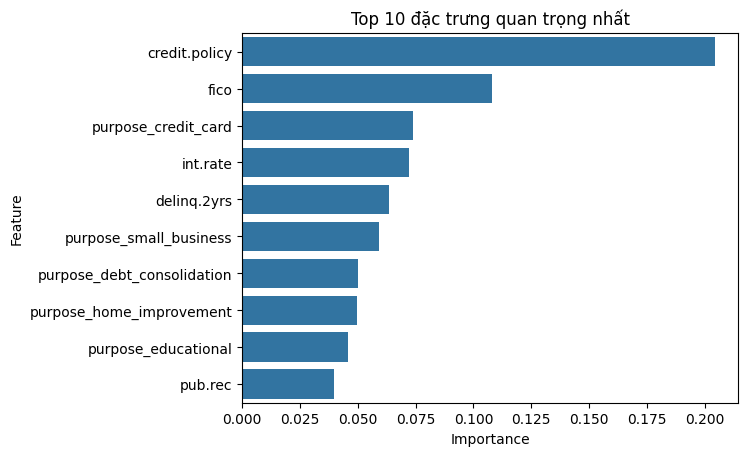

In [9]:

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

# Tính các chỉ số cơ bản
acc = accuracy_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print(f"Accuracy: {acc:.3f}  |  ROC AUC: {roc:.3f}\n")

# Báo cáo chi tiết precision, recall, F1-score
print("=== Báo cáo phân lớp ===")
print(classification_report(y_test, y_pred, digits=3))

# Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Ma trận nhầm lẫn - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Đường cong ROC
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label=f'AUC = {roc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Tầm quan trọng của các đặc trưng (Feature Importance)
fi = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 đặc trưng quan trọng nhất:")
print(fi.head(10))

sns.barplot(data=fi.head(10), x='Importance', y='Feature')
plt.title("Top 10 đặc trưng quan trọng nhất")
plt.show()


**Nhận xét**

### **4.2 Phương pháp Random Forest**

**Bước 1: Import các thư viện cần thiết**

In [6]:
from sklearn.ensemble import RandomForestClassifier


**Nhận xét**

**Bước 2: Chuẩn bị dữ liệu và cân bằng lớp**

In [7]:
target = 'not.fully.paid'
X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Cân bằng dữ liệu bằng kỹ thuật SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Cân bằng lớp xong. Số mẫu train:", len(X_train_res))

Cân bằng lớp xong. Số mẫu train: 11652


**Nhận xét**

**Bước 3: Huấn luyện mô hình Random Forest và tối ưu tham số**

In [8]:
rf = RandomForestClassifier(random_state=42, n_jobs=-1)

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1],
    'max_features': ['sqrt']
}

grid = GridSearchCV(
    rf, param_grid,
    scoring='f1', cv=3, n_jobs=-1, verbose=0
)
grid.fit(X_train_res, y_train_res)

best_rf = grid.best_estimator_

print("Best params:", grid.best_params_)


Best params: {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


**Nhận xét**

**Bước 4: Đánh giá mô hình và trực quan hóa kết quả**

Accuracy: 0.639  |  ROC AUC: 0.639

=== Báo cáo phân lớp - Random Forest ===
              precision    recall  f1-score   support

           0      0.879     0.663     0.756      1456
           1      0.216     0.504     0.302       268

    accuracy                          0.639      1724
   macro avg      0.547     0.584     0.529      1724
weighted avg      0.776     0.639     0.686      1724



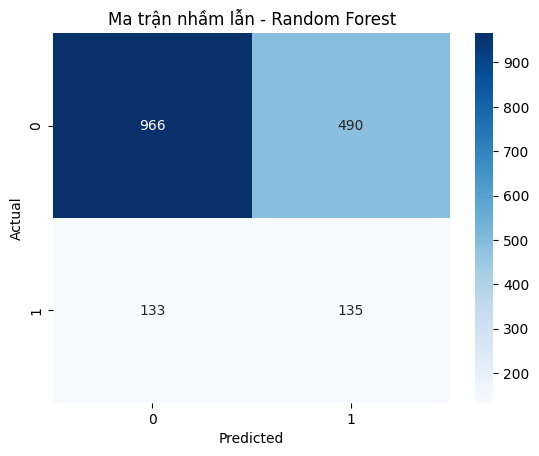

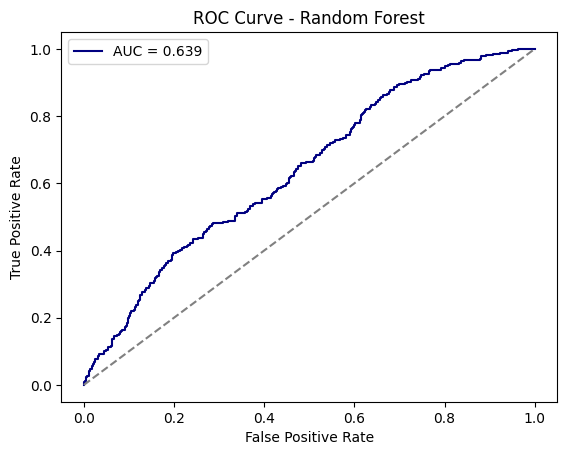


Top 10 đặc trưng quan trọng nhất:
                       Feature  Importance
0                     int.rate    0.210495
4                         fico    0.198091
8                credit.policy    0.133479
7                   revol.util    0.063649
2               log.annual.inc    0.054219
9               inq.last.6mths    0.053594
5            days.with.cr.line    0.045351
1                  installment    0.043423
13  purpose_debt_consolidation    0.039695
17      purpose_small_business    0.034350


/tmp/ipython-input-3120049348.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_rf.head(10), x='Importance', y='Feature', palette='crest')


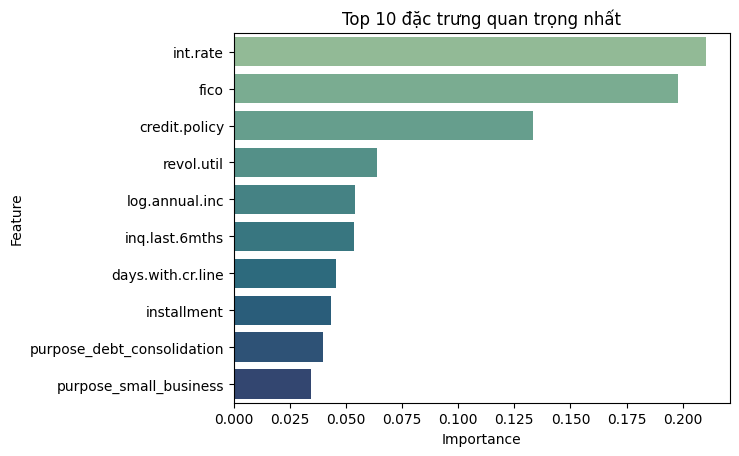

In [10]:
# === Dự đoán trên tập kiểm định ===
y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

# === Tính các chỉ số đánh giá ===
acc_rf = accuracy_score(y_test, y_pred_rf)
roc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Accuracy: {acc_rf:.3f}  |  ROC AUC: {roc_rf:.3f}\n")

# === Báo cáo chi tiết precision, recall, F1-score ===
print("=== Báo cáo phân lớp - Random Forest ===")
print(classification_report(y_test, y_pred_rf, digits=3))

# === Ma trận nhầm lẫn (Confusion Matrix) ===
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.title("Ma trận nhầm lẫn - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# === Đường cong ROC ===
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'AUC = {roc_rf:.3f}', color='navy')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.title("ROC Curve - Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# === Độ quan trọng của các đặc trưng ===
fi_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 đặc trưng quan trọng nhất:")
print(fi_rf.head(10))

sns.barplot(data=fi_rf.head(10), x='Importance', y='Feature', palette='crest')
plt.title("Top 10 đặc trưng quan trọng nhất")
plt.show()



**Nhận xét**